<a href="https://colab.research.google.com/github/MiyoBran/Alura-ONE-G9/blob/main/formacion-estadisticas-y-machine-learning-grupo9-one/04-regresion-lineal-tecnicas-avanzadas-de-modelado/EST_04_2212_Regresion_lineal_avanzado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 style='color: green; font-size: 36px; font-weight: bold;'><b>Regresión Lineal - Técnicas avanzadas de modelado</b></h1>

# <font color='red' style='font-size: 30px;'>1.2 Conociendo el Dataset</font>
<hr style='border: 2px solid red;'>

## Importando la biblioteca pandas

https://pandas.pydata.org/

In [1]:
import pandas as pd

## El Dataset y el Proyecto
<hr>

### Descripción:
<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify; text-indent: 35px;'>El mercado inmobiliario ha sido objeto de diversos estudios e investigaciones en los últimos tiempos. La crisis financiera que afecta la economía ha impactado significativamente las inversiones y los beneficios provenientes de este sector. Este escenario fomenta un mayor interés en estudios de predicción de demanda basados en las características de este mercado, de los inmuebles y de su entorno.</p>

<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify; text-indent: 35px;'>En este contexto, el objetivo principal de nuestro proyecto es desarrollar un sistema de evaluación inmobiliaria utilizando la metodología de regresión lineal, que es una de las técnicas de <b>machine learning</b>.</p>

<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify; text-indent: 35px;'>Nuestro <b>dataset</b> es una muestra aleatoria de tamaño 5000 de inmuebles disponibles para la venta en la ciudad de Cartagena.</p>

### Datos:
<ul style='font-size: 18px; line-height: 2; text-align: justify;'>
    <li><b>Valor</b> - Valor (USD) de oferta del inmueble</li>
    <li><b>Área</b> - Área del inmueble en m²</li>
    <li><b>Dist_Playa</b> - Distancia del inmueble hasta la playa (km) (en línea recta)</li>
    <li><b>Dist_Farmacia</b> - Distancia del inmueble hasta la farmacia más cercana (km) (en línea recta)</li>
</ul>

## Lectura de los datos

In [2]:
# datos = pd.read_csv('/content/dataset.csv',sep=';')
url_original= 'https://github.com/alura-es-cursos/2212-regresion-lineal-tecnicas-avanzadas-de-modelado/blob/main/dataset.csv'
url_csv = url_original.replace('/blob', '').replace('/github.com/', '/raw.githubusercontent.com/')
datos = pd.read_csv(url_csv,sep=';')

## Visualizar los datos

In [3]:
datos.head()

,Valor,Area,Dist_Playa,Dist_Farmacia
0,4600000,280,0.240925,0.793637
1,900000,208,0.904136,0.134494
2,2550000,170,0.059525,0.423318
3,550000,100,2.883181,0.525064
4,2200000,164,0.239758,0.192374


## Verificando el tamaño del dataset

In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Valor          5000 non-null   int64  
 1   Area           5000 non-null   int64  
 2   Dist_Playa     5000 non-null   float64
 3   Dist_Farmacia  5000 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 156.4 KB


In [5]:
# Recorremos con comprension de listas cada columna para imprimir maximo y min
for columna in datos.columns:
    print(f'Columna: {columna}')
    print(f'Máximo: {datos[columna].max()}')
    print(f'Mínimo: {datos[columna].min()}')


Columna: Valor
Máximo: 25000000
Mínimo: 75000
Columna: Area
Máximo: 2000
Mínimo: 16
Columna: Dist_Playa
Máximo: 17.96294163
Mínimo: 0.0
Columna: Dist_Farmacia
Máximo: 0.999987
Mínimo: 0.000331


# <font color='red' style='font-size: 30px;'>1.3 Análisis preliminar</font>
<hr style='border: 2px solid red;'>

## Estadística descriptiva

In [6]:
# Como vemos al analizar los desvios estandar, son valores muy altos (con
# respecto a la media) , por lo que es altamente probable que esten muy
# influenciados por outliers.
datos.describe()

,Valor,Area,Dist_Playa,Dist_Farmacia
count,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,1.402926e+06,121.944800,3.021920,0.497160
std,1.883269e+06,90.536969,3.170933,0.291355
min,7.500000e+04,16.000000,0.000000,0.000331
25%,4.600000e+05,70.000000,0.438417,0.238640
50%,8.200000e+05,93.000000,1.476958,0.503260
75%,1.590000e+06,146.000000,5.605379,0.747737
max,2.500000e+07,2000.000000,17.962942,0.999987


## Matriz de correlación

<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify;'>El <b>coeficiente de correlación</b> es una medida de asociación lineal entre dos variables y se sitúa entre <b>-1</b> y <b>+1</b>, donde <b>-1</b> indica una asociación negativa perfecta y <b>+1</b> indica una asociación positiva perfecta.</p>


In [7]:
datos.corr()

,Valor,Area,Dist_Playa,Dist_Farmacia
Valor,1.000000,0.710974,-0.366542,-0.024366
Area,0.710974,1.000000,-0.283371,-0.030990
Dist_Playa,-0.366542,-0.283371,1.000000,0.025645
Dist_Farmacia,-0.024366,-0.030990,0.025645,1.000000


---

### 📊 Cheat Sheet: Diagnóstico Rápido de Datos

**1. Lectura de `datos.describe()` (Distribución y Dispersión)**

* **`mean` vs `50%` (Media vs Mediana):** Es la prueba de fuego de la asimetría poblacional.
* Si **`mean` > `50%**`: Asimetría positiva. Existen valores atípicos muy altos (ej. un inmueble de 25M USD) que "arrastran" el promedio hacia arriba, distorsionando la lectura general.
* Si **`mean` ≈ `50%**`: Distribución simétrica (tendencia a distribución normal).


* **`std` (Desviación Estándar):** Mide la dispersión estadística de los datos. Un `std` mayor o muy cercano a la media indica altísima volatilidad y presencia de *outliers*.
* **`min` / `max`:** Filtro primario para detectar anomalías de registro rápido (ej. inmuebles con área 0 o precios ilógicos).
* **`25% - 75%` (Rango Intercuartílico - IQR):** Define la "zona de concentración". El 50% de las observaciones centrales caen aquí. Los datos que se alejan drásticamente del percentil 75% suelen requerir tratamiento (eliminación o transformación) para no sesgar la regresión.

**2. Lectura de `datos.corr()` (Fuerza y Dirección Lineal - Coeficiente de Pearson $r$)**

* **$r$ cercano a 1 (Correlación Positiva Fuerte):** Movimiento proporcional directo. Sube X, sube Y (Ej: Área y Valor = 0.71). Gran poder predictivo.
* **$r$ cercano a -1 (Correlación Negativa Fuerte):** Movimiento inversamente proporcional. Sube X, baja Y (Ej: Distancia Playa y Valor = -0.36).
* **$r$ cercano a 0 (Ruido Estadístico):** Ausencia de relación *lineal* (Ej: Dist. Farmacia y Valor = -0.02). Según el Principio de Parsimonia, estas variables no aportan al modelo y son candidatas a ser descartadas (evaluar p-valor más adelante).
* **⚠️ Alerta de Multicolinealidad:** Si al leer la matriz ves que dos variables predictoras (X) tienen una correlación altísima *entre sí*, generarán redundancia en la matriz del modelo.

---

# <font color='red' style='font-size: 30px;'>2.1 Comportamiento de la variable Dependiente (y)</font>
<hr style='border: 2px solid red;'>

## Importando la biblioteca seaborn
https://seaborn.pydata.org/

<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify;'>Seaborn es una biblioteca de Python para la visualización de datos basada en matplotlib. Proporciona una interfaz de alto nivel para crear gráficos estadísticos.</p>



In [8]:
import seaborn as sns

## Configuraciones para el formato de los gráficos

In [9]:
# palette -> Accent, Accent_r, Blues, Blues_r, BrBG, BrBG_r, BuGn, BuGn_r, BuPu, BuPu_r, CMRmap, CMRmap_r, Dark2, Dark2_r, GnBu, GnBu_r, Greens, Greens_r, Greys, Greys_r, OrRd, OrRd_r, Oranges, Oranges_r, PRGn, PRGn_r, Paired, Paired_r, Pastel1, Pastel1_r, Pastel2, Pastel2_r, PiYG, PiYG_r, PuBu, PuBuGn, PuBuGn_r, PuBu_r, PuOr, PuOr_r, PuRd, PuRd_r, Purples, Purples_r, RdBu, RdBu_r, RdGy, RdGy_r, RdPu, RdPu_r, RdYlBu, RdYlBu_r, RdYlGn, RdYlGn_r, Reds, Reds_r, Set1, Set1_r, Set2, Set2_r, Set3, Set3_r, Spectral, Spectral_r, Wistia, Wistia_r, YlGn, YlGnBu, YlGnBu_r, YlGn_r, YlOrBr, YlOrBr_r, YlOrRd, YlOrRd_r, afmhot, afmhot_r, autumn, autumn_r, binary, binary_r, bone, bone_r, brg, brg_r, bwr, bwr_r, cividis, cividis_r, cool, cool_r, coolwarm, coolwarm_r, copper, copper_r, cubehelix, cubehelix_r, flag, flag_r, gist_earth, gist_earth_r, gist_gray, gist_gray_r, gist_heat, gist_heat_r, gist_ncar, gist_ncar_r, gist_rainbow, gist_rainbow_r, gist_stern, gist_stern_r, gist_yarg, gist_yarg_r, gnuplot, gnuplot2, gnuplot2_r, gnuplot_r, gray, gray_r, hot, hot_r, hsv, hsv_r, icefire, icefire_r, inferno, inferno_r, jet, jet_r, magma, magma_r, mako, mako_r, nipy_spectral, nipy_spectral_r, ocean, ocean_r, pink, pink_r, plasma, plasma_r, prism, prism_r, rainbow, rainbow_r, rocket, rocket_r, seismic, seismic_r, spring, spring_r, summer, summer_r, tab10, tab10_r, tab20, tab20_r, tab20b, tab20b_r, tab20c, tab20c_r, terrain, terrain_r, viridis, viridis_r, vlag, vlag_r, winter, winter_r
sns.set_palette("Accent")
# style -> white, dark, whitegrid, darkgrid, ticks
sns.set_style("darkgrid")

## Box plot de la variable *dependiente* (y)

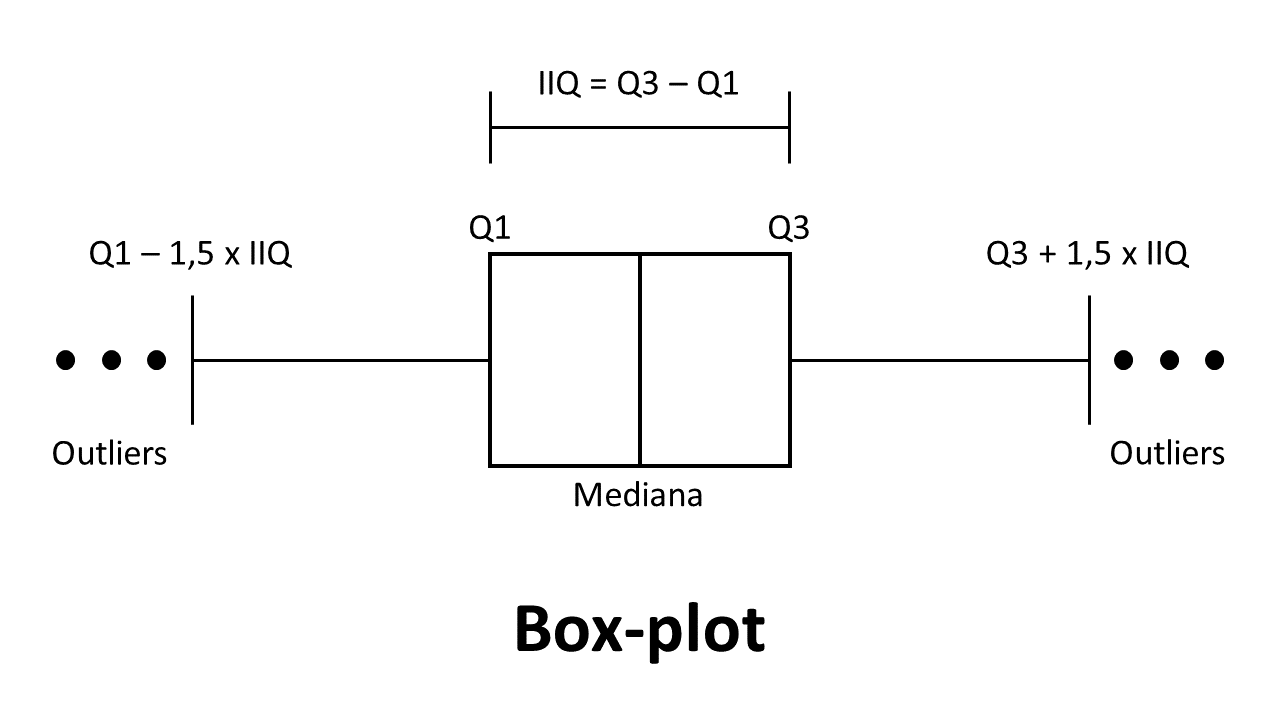

https://seaborn.pydata.org/generated/seaborn.boxplot.html?highlight=boxplot#seaborn.boxplot

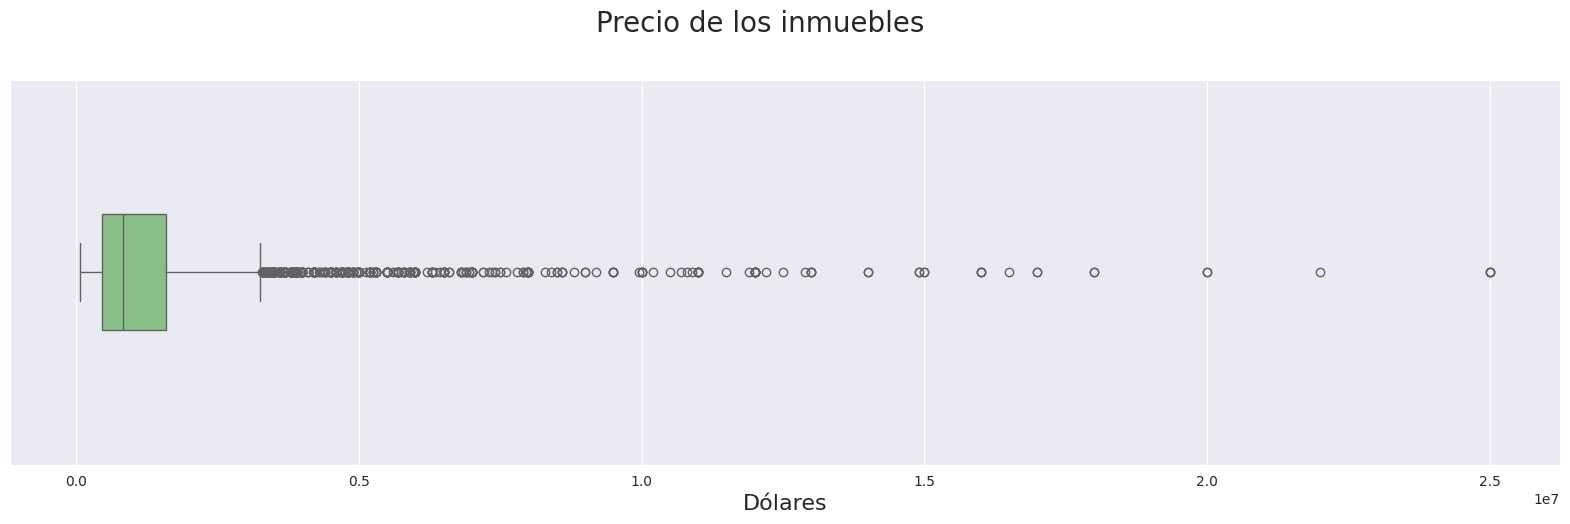

In [10]:
ax = sns.boxplot(data=datos['Valor'],orient='h',width=0.3)
ax.figure.set_size_inches(20,5)
ax.figure.suptitle('Precio de los inmuebles',fontsize=20, y=1.02)
ax.set_xlabel('Dólares', fontsize=16)
# Añadimos el ; para evitar informacion innecesaria
ax;

# <font color='red' style='font-size: 30px;'>2.2 Distribución de Frecuencias</font>
<hr style='border: 2px solid red;'>

## Distribución de frecuencias de la variable *dependiente* (y)

https://seaborn.pydata.org/generated/seaborn.displot.html#seaborn.displot

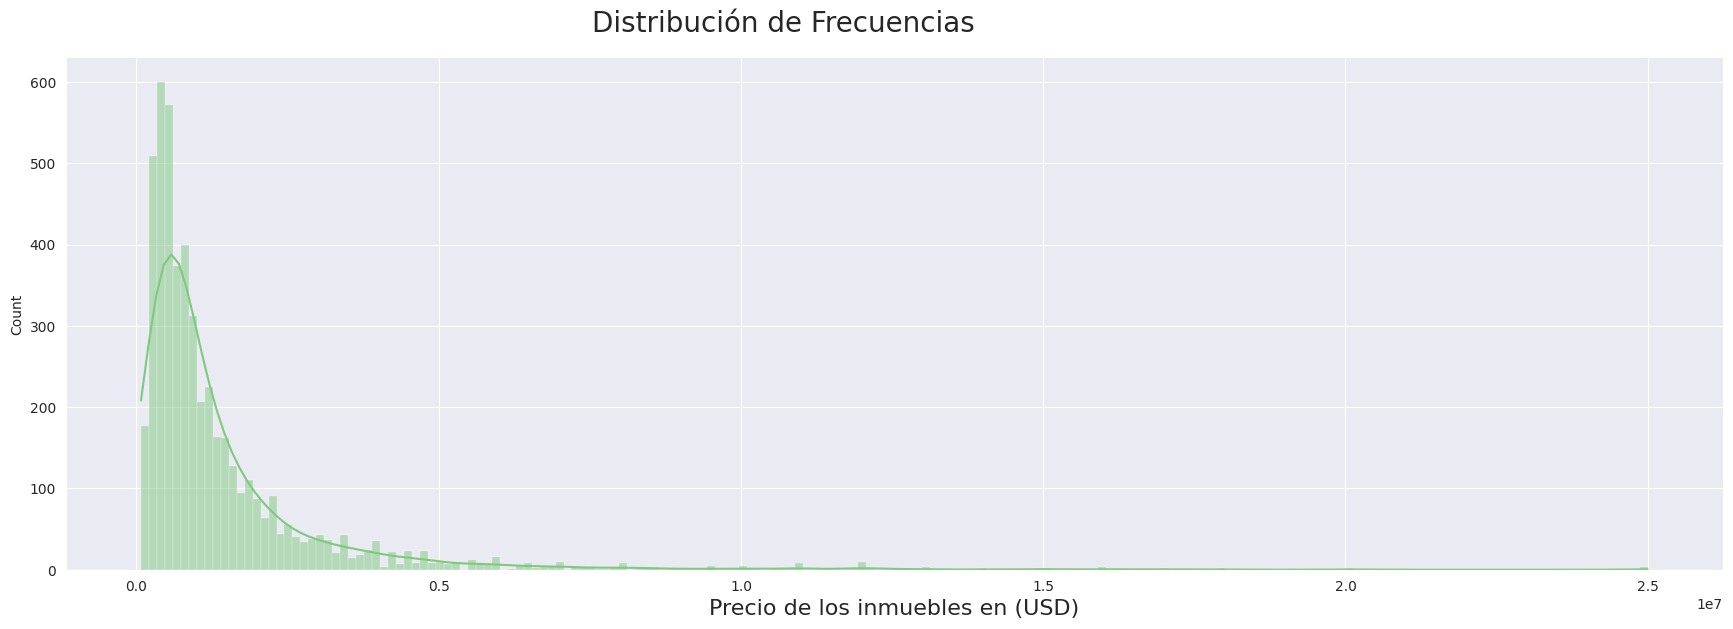

In [11]:
ax = sns.displot(datos['Valor'],kde=True)
ax.figure.set_size_inches(20,6)
# Personalizamos titulo ( incluyendo la posicion en % respecto de la figura +5%)
ax.fig.suptitle('Distribución de Frecuencias',fontsize=20,y=1.05)
ax.set_xlabels('Precio de los inmuebles en (USD)',fontsize=16)
ax;

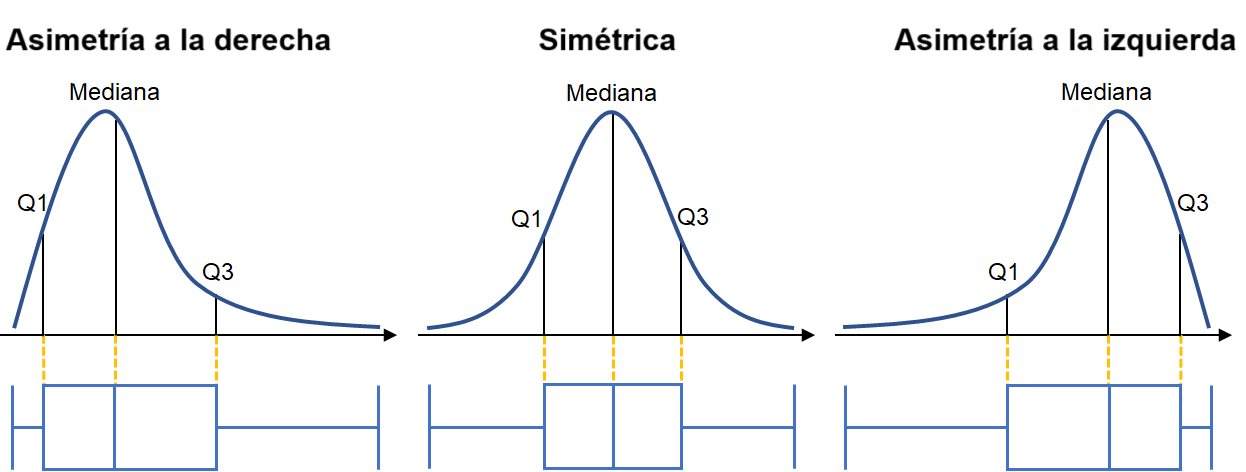

# <font color='red' style='font-size: 30px;'>2.3 Dispersión entre las Variables</font>
<hr style='border: 2px solid red;'>

## Gráficos de dispersión entre las variables del dataset

## seaborn.pairplot

https://seaborn.pydata.org/generated/seaborn.pairplot.html?highlight=pairplot#seaborn.pairplot

<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify;'>Grafica la relación entre pares de variables en un dataset.</p>

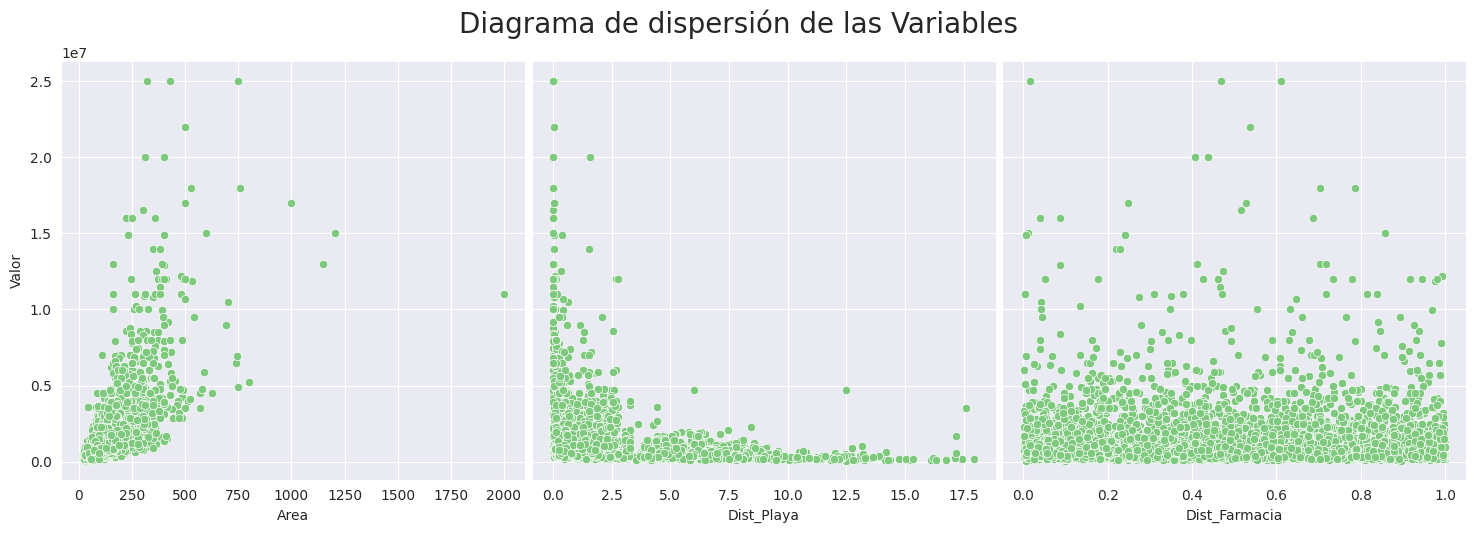

In [12]:
# Estamos graficando todas las otras variables con respecto a Valor (hacemos
# pares de comparaciones)
ax = sns.pairplot(datos,y_vars='Valor',x_vars=['Area','Dist_Playa','Dist_Farmacia'],height=5)
ax.fig.suptitle('Diagrama de dispersión de las Variables',fontsize=20,y=1.05)
# observamos graficos diferentes
ax;

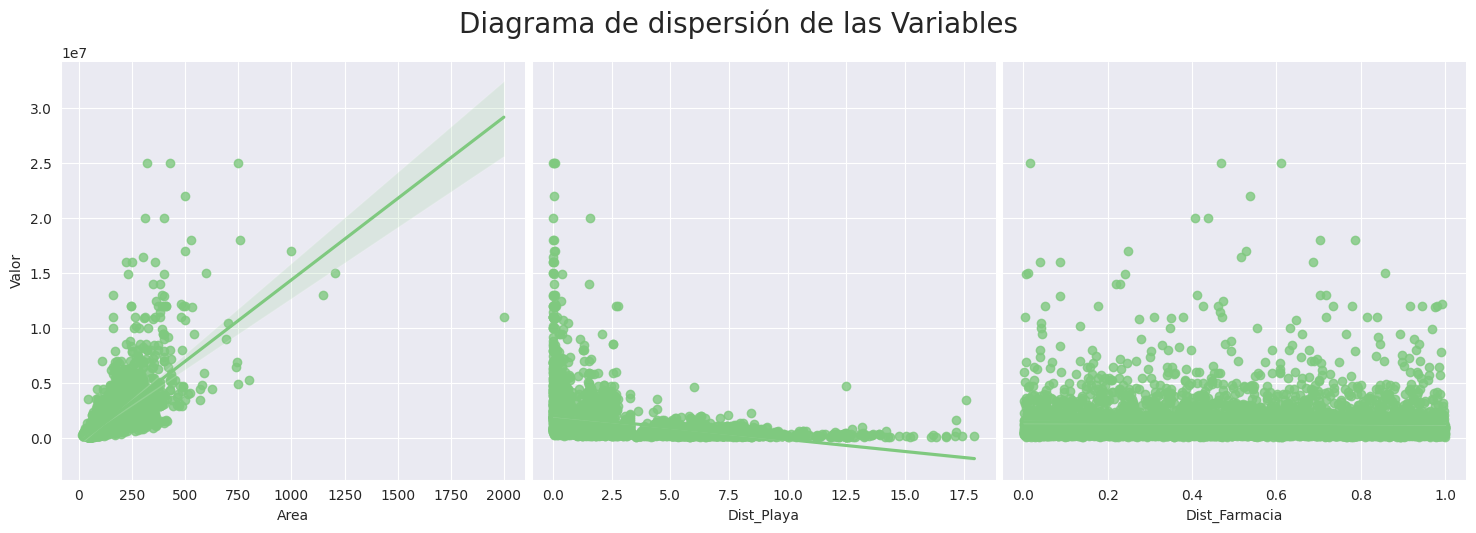

In [13]:
# añadimos una linea de regresion para consolidar-visualizar mejor las
# tendencias. usando kind='reg'
ax = sns.pairplot(datos,y_vars='Valor',x_vars=['Area','Dist_Playa','Dist_Farmacia'],kind='reg',height=5)
ax.fig.suptitle('Diagrama de dispersión de las Variables',fontsize=20,y=1.05)
# Observamos que a medida que aumenta el area aumenta el valor, de una forma
# relativamente lineal (con forma de cono). Por otro lado respecto de la
# distancia de la playa, a medida que la misma disminuye, el valor es mas alto,
# y cuando me alejo tiende a ser mas bajo. Por ultimocon respecto a la
# dist_Farmacia no se observa ningun patron.
ax;

### 📚 Apunte teorico y Refactorizacion Senior

1. **Asimetría Positiva (Right Skew) en Boxplot e Histograma:** * **Intuición:** El precio de los inmuebles tiene un "piso" rígido (no hay casas gratis), pero no tiene un "techo" (pueden existir mansiones de decenas de millones de USD). Esa "cola" larga hacia la derecha arrastra la Media Matemática hacia arriba, separándola de la Mediana. Si tu software usa solo el promedio sin tratar esta asimetría, sobrevalorará las propiedades estándar de una PyME.
2. **Heterocedasticidad (El efecto "Embudo") en el Pairplot:** * **Intuición:** La Regresión Lineal asume "Homocedasticidad" (que el margen de error del algoritmo es constante, como un tubo a lo largo de la recta). Sin embargo, si miras el gráfico de `Area` vs `Valor`, verás que al principio (áreas pequeñas) los puntos están pegados a la línea, pero a medida que el área crece, los puntos se dispersan enormemente formando un cono o embudo. ¿Por qué? Porque es fácil tasar un departamento de 40m² (los precios no varían mucho), pero un terreno de 1000m² puede ser un galpón abandonado o un penthouse de lujo. A mayor área, mayor varianza (incertidumbre) en el precio en USD.

Aquí tienes el bloque completo refactorizado para tu notebook. Hemos encapsulado todo en una función tipada, eliminando el código espagueti y usando `df_propiedades` en lugar de `datos`.

---


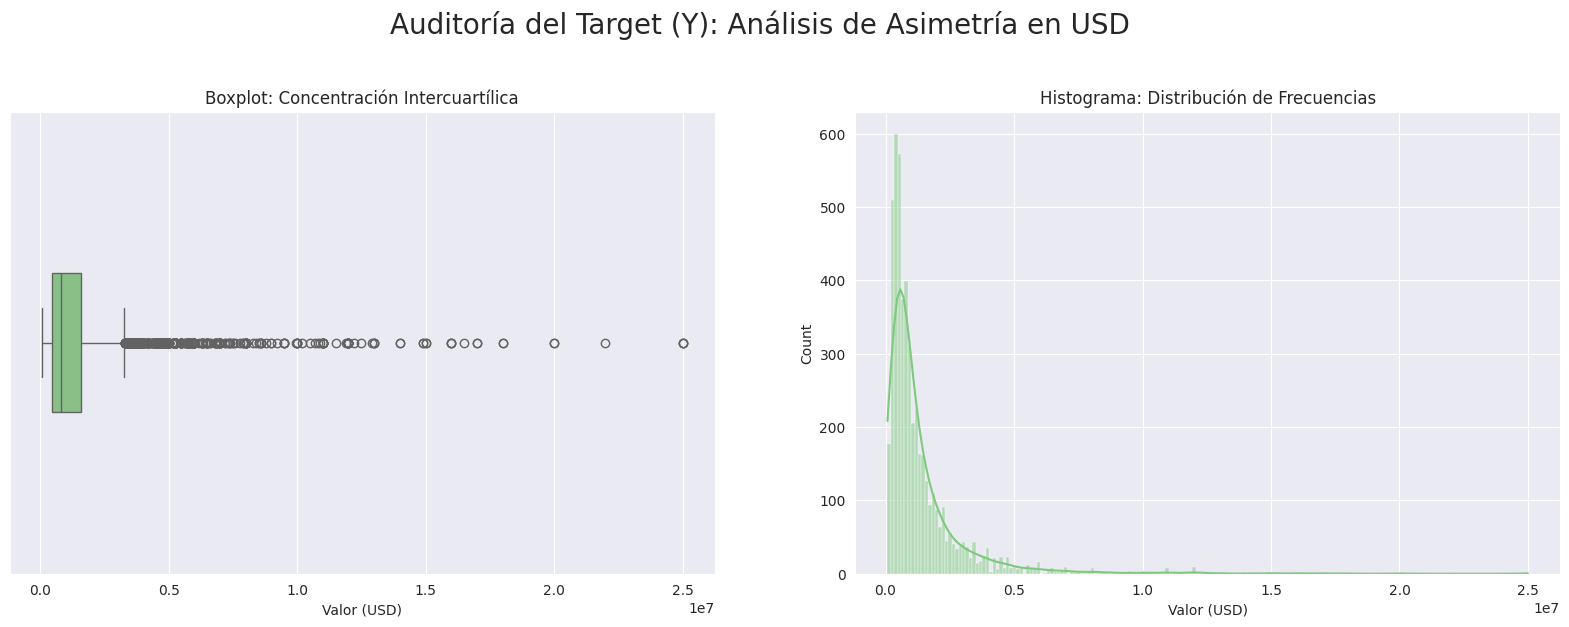

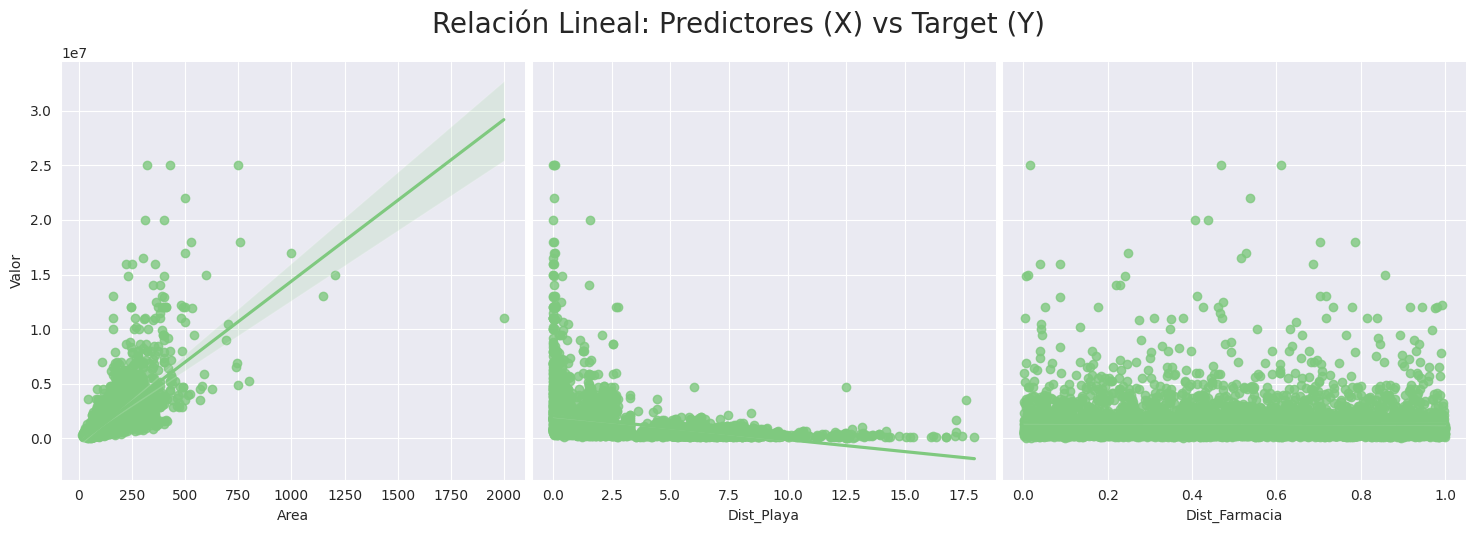

In [14]:

# Asumimos importado pandas as pd y seaborn as sns
# También requerimos importar matplotlib para un control fino de la arquitectura visual
import matplotlib.pyplot as plt

df_propiedades  = datos.copy()

def auditar_distribucion_y_relaciones(df: pd.DataFrame, col_target: str, cols_predictores: list[str]) -> None:
    """
    Ejecuta una auditoría visual de la variable dependiente (Y) y sus predictores (X).
    Evalúa estadísticamente la asimetría poblacional y la varianza (Homocedasticidad vs Heterocedasticidad).
    """
    # 1. Configuración global de estilo (Se define una sola vez para mantener coherencia visual)
    sns.set_palette("Accent")
    sns.set_style("darkgrid")

    # ---------------------------------------------------------------------
    # DIAGNÓSTICO 1: Distribución del Target (Auditoría de Asimetría)
    # ---------------------------------------------------------------------
    # Utilizamos subplots para consolidar el Boxplot y el Histograma en una sola figura limpia
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    fig.suptitle('Auditoría del Target (Y): Análisis de Asimetría en USD', fontsize=20, y=1.05)

    # Boxplot: Permite visualizar los outliers (valores atípicos) que "estiran" la media poblacional
    sns.boxplot(data=df, x=col_target, ax=axes[0], width=0.3)
    axes[0].set_title('Boxplot: Concentración Intercuartílica')
    axes[0].set_xlabel('Valor (USD)')

    # Histograma + KDE: Visualiza la Asimetría Positiva (Cola larga hacia la derecha)
    sns.histplot(data=df, x=col_target, kde=True, ax=axes[1])
    axes[1].set_title('Histograma: Distribución de Frecuencias')
    axes[1].set_xlabel('Valor (USD)')

    plt.show()

    # ---------------------------------------------------------------------
    # DIAGNÓSTICO 2: Dispersión y Varianza (Auditoría de Heterocedasticidad)
    # ---------------------------------------------------------------------
    # Pairplot con línea de regresión (kind='reg').
    # Buscamos observar si el error es constante (Homocedasticidad) o si forma un cono (Heterocedasticidad).
    grafico_relaciones = sns.pairplot(
        data=df,
        y_vars=col_target,
        x_vars=cols_predictores,
        kind='reg',
        height=5
    )
    grafico_relaciones.fig.suptitle('Relación Lineal: Predictores (X) vs Target (Y)', fontsize=20, y=1.05)
    plt.show()

# Ejecución de la función con variables claramente definidas
# Supongamos que tu DataFrame ya fue cargado previamente como 'df_propiedades'
variables_predictoras = ['Area', 'Dist_Playa', 'Dist_Farmacia']
auditar_distribucion_y_relaciones(df_propiedades, col_target='Valor', cols_predictores=variables_predictoras)


---

Con esta refactorización, tienes un código modular que podrías reutilizar directamente en el backend de tu software para auditar cualquier otro *dataset*, y además cuenta con los fundamentos estadísticos teóricos claros para tu examen.

# <font color='red' style='font-size: 30px;'>3.1 Transformando los Datos</font>
<hr style='border: 2px solid red;'>

## Distribución Normal
<hr>

### ¿Por qué?
<p style='font-size: 18px; line-height: 2; margin: 10px 50px; text-align: justify;'>Las pruebas paramétricas asumen que los datos de la muestra fueron recolectados de una población con una distribución de probabilidad conocida. Gran parte de las pruebas estadísticas asumen que los datos siguen una distribución normal (t de Student, intervalos de confianza, etc.).</p>


## Importando la biblioteca numpy

In [15]:
import numpy as np

## Aplicando la transformación logarítmica a los datos del *dataset*

https://numpy.org/doc/stable/reference/generated/numpy.log.html

In [16]:
# Debemos tener en cuenta que el log(0) tiende a infinito, por lo que debemos
# tener mucho cuidado (o tratar adecuadamente) aquellos valores que sean 0
np.log(1)

np.float64(0.0)

In [17]:
# Creamos las columnas para los logaritmos de cada variable (aqui tendremos el
# error en las columnas que contienen 0 , por lo que sumamos a esas columnas el
# +1)
datos['log_Valor'] = np.log(datos['Valor'])
datos['log_Area'] = np.log(datos['Area'])
datos['log_Dist_Playa'] = np.log(datos['Dist_Playa']+1)
datos['log_Dist_Farmacia'] = np.log(datos['Dist_Farmacia']+1)

In [18]:
# Ahora vemos que la escala logaritmica es mas "razonable" , y buscamos
# conseguir un grafico con distribucion "normal".
datos.head()

,Valor,Area,Dist_Playa,Dist_Farmacia,log_Valor,log_Area,log_Dist_Playa,log_Dist_Farmacia
0,4600000,280,0.240925,0.793637,15.341567,5.634790,0.215857,0.584245
1,900000,208,0.904136,0.134494,13.710150,5.337538,0.644028,0.126187
2,2550000,170,0.059525,0.423318,14.751604,5.135798,0.057821,0.352991
3,550000,100,2.883181,0.525064,13.217674,4.605170,1.356655,0.422036
4,2200000,164,0.239758,0.192374,14.603968,5.099866,0.214916,0.175946


## Distribución de frecuencia de la variable *dependiente transformada* (y)

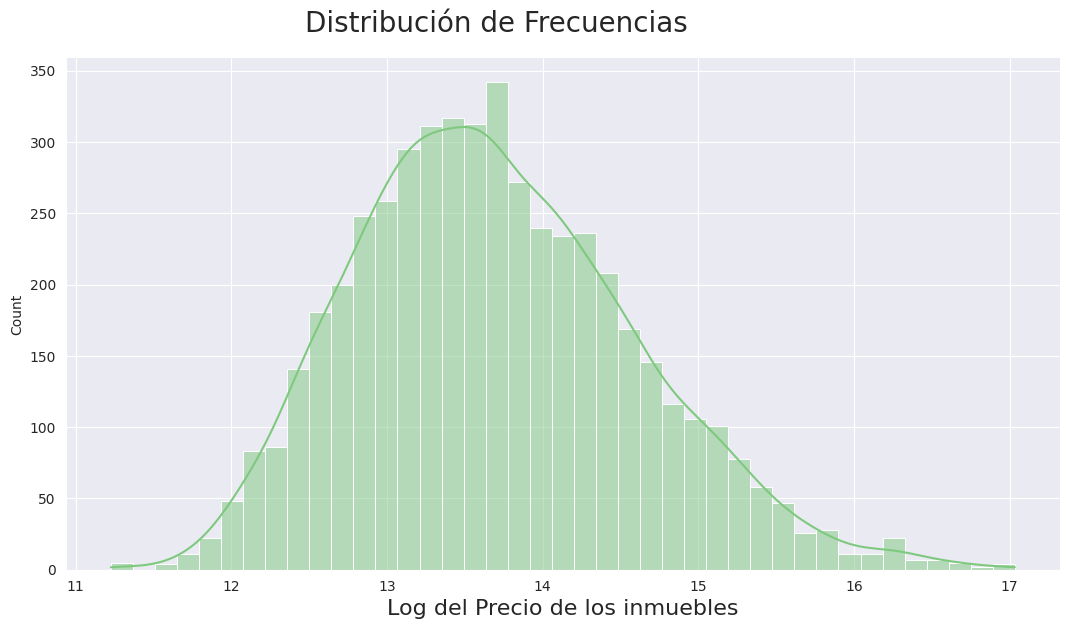

In [19]:
# Graficaremos nuestros valores logaritmicos.
ax = sns.displot(datos['log_Valor'],kde=True)
ax.figure.set_size_inches(12,6)
ax.fig.suptitle('Distribución de Frecuencias',fontsize=20,y=1.05)
ax.set_xlabels('Log del Precio de los inmuebles',fontsize=16)
ax;

# <font color='red' style='font-size: 30px;'>3.2 Verificando La Relación Lineal</font>
<hr style='border: 2px solid red;'>

## Gráficos de dispersión entre las variables transformadas del dataset

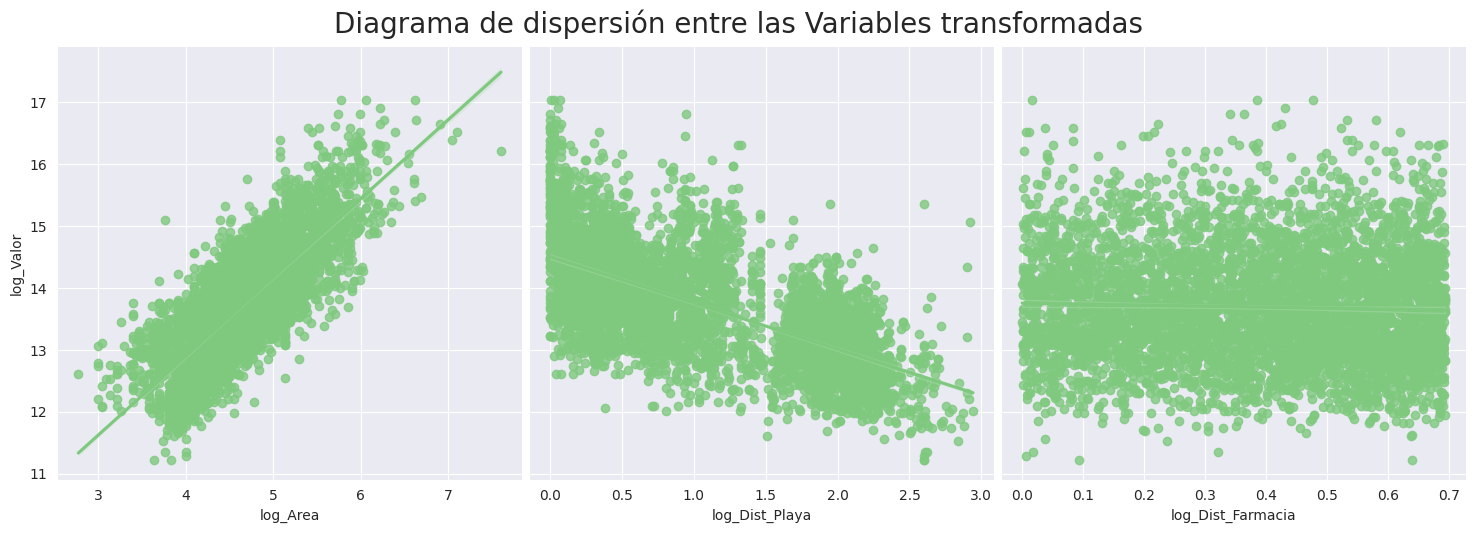

In [20]:
# replicamos el ejercicio del diagrama de dispersion, pero utilizando nuestras variables transformadas .
ax = sns.pairplot(datos,y_vars='log_Valor',x_vars=['log_Area','log_Dist_Playa','log_Dist_Farmacia'],kind='reg',height=5)
ax.fig.suptitle('Diagrama de dispersión entre las Variables transformadas',fontsize=20,y=1.05)
# Al utilizar los logaritmicos , notamos que la recta del area y el valor la correlacion positiva
# es mucho mas evidente, lo mismo ocurre con la correlacion negativa entre la distancia de la playa y el valor.
ax;

---

### 📚 Apunte Teórico y Refactorización Senior

**1. Fundamento Estadístico: Transformación Logarítmica**

* **Normalización de la Varianza:** OLS asume que los errores se distribuyen normalmente (Homocedasticidad). Variables con fuerte asimetría positiva (como el precio en USD) violan este supuesto. El logaritmo "comprime" los valores altos, acercando la distribución a una campana de Gauss simétrica.
* **Linealización de Relaciones:** Relaciones que en la realidad son exponenciales o curvas (ej. el precio se dispara a medida que nos acercamos a la playa) se vuelven relaciones lineales tras aplicar logaritmos, permitiendo que la recta de regresión ajuste perfectamente.
* **El problema del Cero:** Dado que $\lim_{x \to 0^+} \ln(x) = -\infty$, si un inmueble tiene distancia 0 a la playa, el cálculo colapsa. La solución matemática es evaluar $\ln(x + 1)$. En Python Senior, usamos `np.log1p(x)`.

**2. Pipeline de Transformación Segura (Clean Code)**


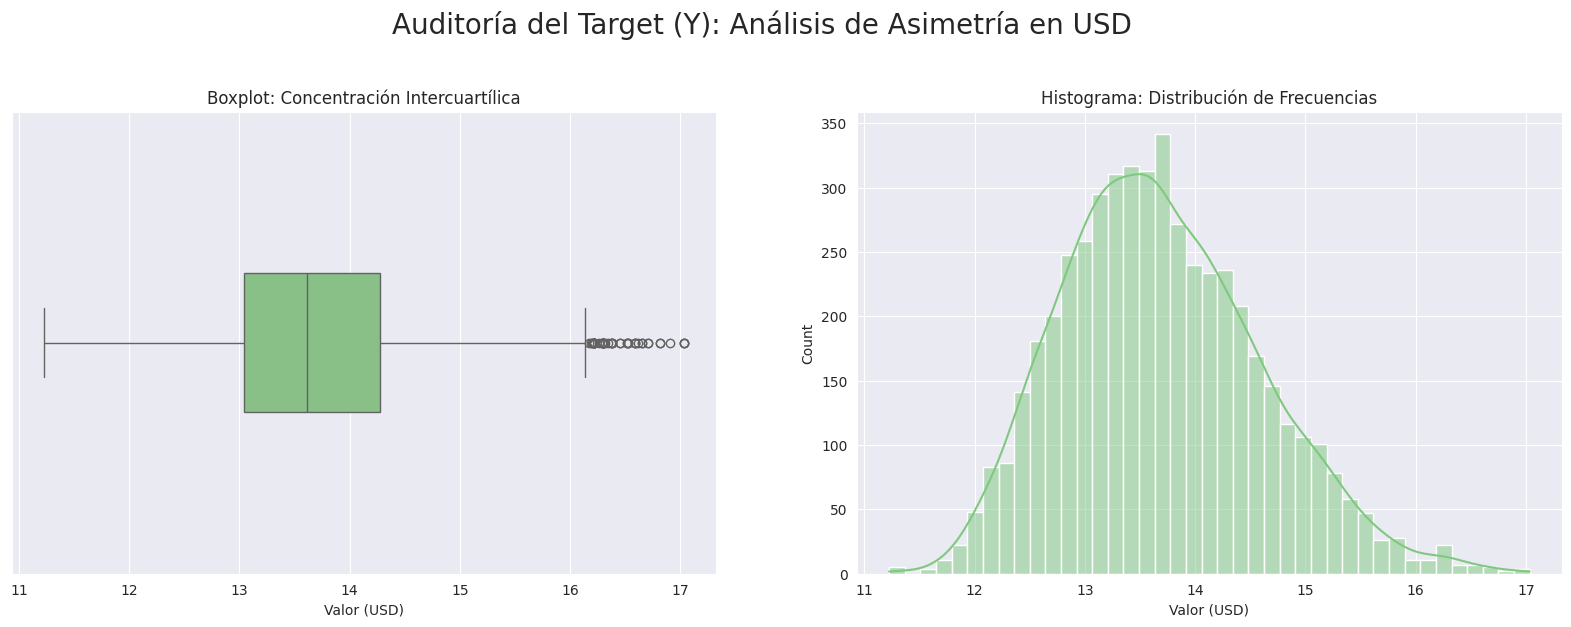

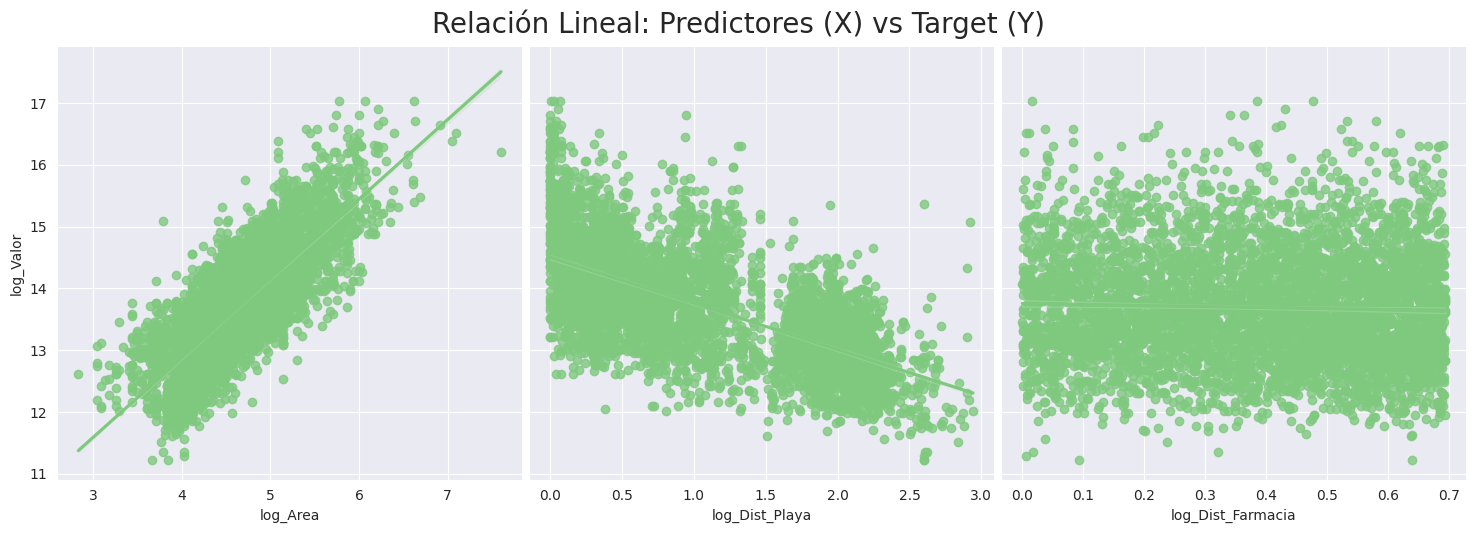

In [21]:

# Asumimos importado pandas as pd, seaborn as sns, matplotlib.pyplot as plt y numpy as np
#import numpy as np

def aplicar_transformacion_log(df: pd.DataFrame, columnas_a_transformar: list[str]) -> pd.DataFrame:
    """
    Crea una copia del DataFrame y aplica una transformación logarítmica (log(x+1))
    a las columnas especificadas para corregir asimetrías y heterocedasticidad.
    Retorna un nuevo DataFrame, protegiendo los datos originales de mutaciones accidentales.
    """
    # Trabajamos sobre una copia para evitar el SettingWithCopyWarning y proteger el estado original
    df_transformado = df.copy()

    for col in columnas_a_transformar:
        nombre_nueva_col = f"log_{col}"
        # np.log1p(x) es el equivalente matemático y numéricamente estable de np.log(x + 1)
        df_transformado[nombre_nueva_col] = np.log1p(df_transformado[col])

    return df_transformado

# 1. Definimos las columnas que necesitan normalización
columnas_para_log = ['Valor', 'Area', 'Dist_Playa', 'Dist_Farmacia']

# 2. Ejecutamos el pipeline (asumiendo que df_propiedades es nuestro dataset original)
df_propiedades_log = aplicar_transformacion_log(df_propiedades, columnas_para_log)

# 3. Validamos visualmente el "Después" REUTILIZANDO nuestra función de auditoría anterior
variables_predictoras_log = ['log_Area', 'log_Dist_Playa', 'log_Dist_Farmacia']

# Al ejecutar esto, veremos instantáneamente la campana de Gauss en el histograma
# y la corrección del efecto "embudo" en los pairplots.
auditar_distribucion_y_relaciones(
    df=df_propiedades_log,
    col_target='log_Valor',
    cols_predictores=variables_predictoras_log
)


# <font color='red' style='font-size: 30px;'>4.1 Creando los *Datasets* de Entrenamiento y Prueba</font>
<hr style='border: 2px solid red;'>

## Importando *train_test_split* de la biblioteca *scikit-learn*

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

In [22]:
from sklearn.model_selection import train_test_split

## Creando una Serie (pandas) para almacenar el Precio de los Inmuebles (y)

In [23]:
# usaremos la estimacion con nuestro log_Valor
y = datos['log_Valor']

## Creando un DataFrame (pandas) para almacenar las variables explicativas (X)

In [24]:
# Consistentemente usaremos los log de nuestros datos
X = datos[['log_Area','log_Dist_Playa','log_Dist_Farmacia']]

## Criando los datasets de Entrenamiento y Prueba

In [26]:
# Con test_size seteamos en 20% el tamaño del conj de prueba
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2811)

# Regresión Lineal
<hr>

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>El análisis de regresión se refiere al estudio de la dependencia de una variable (la variable <b>dependiente</b>) con respecto a una o más variables, las variables explicativas, con el objetivo de estimar y/o predecir el valor medio de la primera en función de los valores conocidos o fijados en las últimas.</p>


## scikit-learn (https://scikit-learn.org/stable/)

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'><b>scikit-learn</b> es un módulo de Python especializado en soluciones de <b>machine learning</b>.</p>




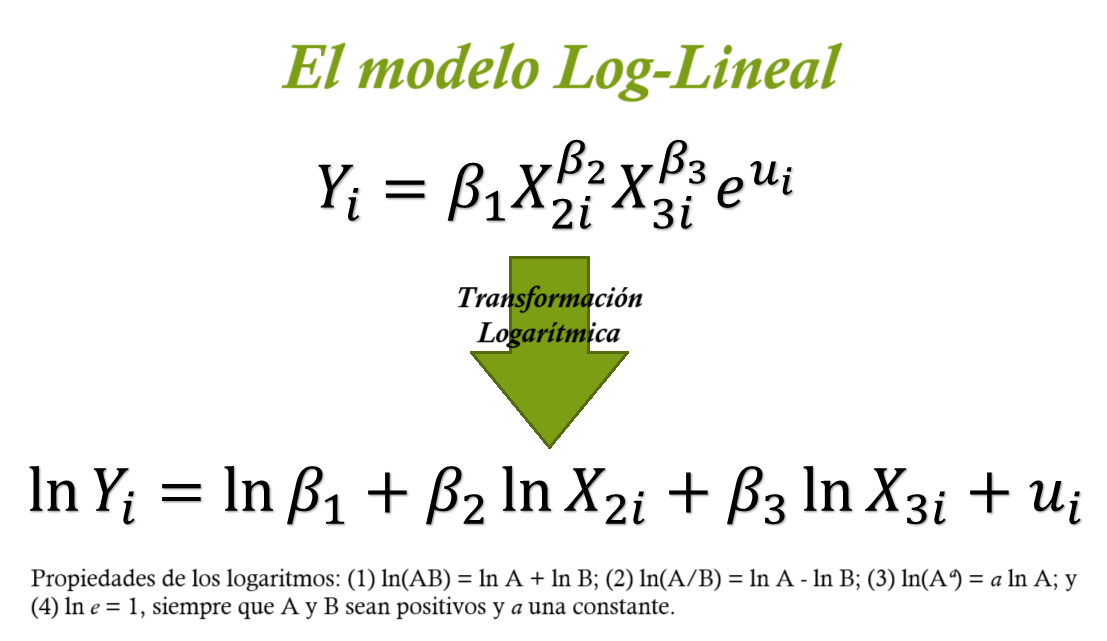

## 📈 Modelo Log-Lineal

El **modelo log-lineal** es una variante de la regresión lineal en la que se aplica una transformación logarítmica a una o más variables (dependiente y/o independientes) con el objetivo de:

- Reducir la asimetría de la distribución.
- Estabilizar la varianza (mitigar heterocedasticidad).
- Aproximar la normalidad de los errores.
- Modelar relaciones no lineales en forma multiplicativa.

---

### 🔹 Forma general

Existen tres configuraciones comunes:

1. **Log en la variable dependiente (modelo log-lineal clásico):**

$$\log(Y) = \beta_0 + \beta_1 X + \varepsilon$$

- Interpreta los coeficientes como cambios porcentuales aproximados en \(Y\) ante un cambio unitario en \(X\).

---

2. **Log en las variables independientes (modelo lineal-log):**

$$Y = \beta_0 + \beta_1 \log(X) + \varepsilon$$

- Un cambio porcentual en \(X\) produce un cambio absoluto en \(Y\).

---

3. **Log en ambas variables (modelo log-log):**

$$
\log(Y) = \beta_0 + \beta_1 \log(X) + \varepsilon
$$

- $(\beta_1)$ se interpreta como **elasticidad**:  
  > Un 1% de cambio en $(X)$ genera aproximadamente un $(\beta_1)$% de cambio en $(Y)$.

---

### 🔹 ¿Por qué usar transformación logarítmica?

- Cuando la relación entre variables es **multiplicativa**:
  
  $$
  Y = \alpha X^{\beta}
  $$

  Al aplicar logaritmos:

  $$
  \log(Y) = \log(\alpha) + \beta \log(X)
  $$

  Lo que convierte el modelo en lineal en los parámetros.

- Cuando los datos presentan:
  - Crecimiento exponencial
  - Alta dispersión
  - Sesgo positivo marcado

---

### 🔹 Consideraciones importantes

- Solo puede aplicarse a valores **positivos**.
- Cambia la interpretación de los coeficientes.
- Puede mejorar el cumplimiento de los supuestos clásicos de regresión:
  - Normalidad de errores
  - Homocedasticidad
  - Linealidad

---

### ✅ En resumen

El modelo log-lineal permite transformar relaciones no lineales o multiplicativas en relaciones lineales estimables mediante MCO, facilitando la interpretación económica y mejorando el ajuste cuando las variables presentan distribuciones asimétricas.

https://www.statsmodels.org/stable/index.html

In [28]:
# Utilizamos statsmodels para poder usar la transformacion logaritmica ,
# nos permite hacer exploracion estadistica a los datos.
import statsmodels.api as sm

## Estimando el modelo con statsmodels

In [29]:
# Debemos generar la columna adicional "necesaria" constante
X_train_con_constante = sm.add_constant(X_train)

In [30]:
# Aqui vemos con nuestra constante, necesaria para el OLS
X_train_con_constante

,const,log_Area,log_Dist_Playa,log_Dist_Farmacia
2661,1.0,5.945421,0.000000,0.382273
912,1.0,3.135494,0.972865,0.605015
3042,1.0,4.317488,1.794961,0.486594
141,1.0,3.401197,0.310455,0.599609
3854,1.0,5.676754,0.032193,0.101903
...,...,...,...,...
3657,1.0,5.075174,2.023480,0.333605
979,1.0,4.174387,2.296141,0.156465
2389,1.0,4.394449,1.367741,0.409727
447,1.0,3.951244,2.166841,0.217381


In [31]:
# usamos el metodo OLS(minimos cuadrados ordinarios) , con nuestro X_Train
modelo_statsmodels = sm.OLS(y_train,X_train_con_constante,hasconst=True).fit()

# <font color='red' style='font-size: 30px;'>4.2 Evaluando el Modelo Estimado</font>
<hr style='border: 2px solid red;'>

## Evaluando los resultados del modelo

In [32]:
# obtenemos el resumen de nuestro modelo
# Aqui prestamos atencion al estadistico F , que nos indica si tiene
# significancia estadistica. (vemos 0 por el redondeo) , cualquier valor
# inferior a 0.05 tiene significancia. si esto lo vemos en conjunto con el test-T
# , que evalua cada atributo por separado , tambien vemos que todas las
#probabilidades son de 0.000 , pero no asi en el log de la dist a la playa.
print(modelo_statsmodels.summary())

                            OLS Regression Results                            
Dep. Variable:              log_Valor   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     5495.
Date:                Tue, 03 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:23:54   Log-Likelihood:                -2044.9
No. Observations:                4000   AIC:                             4098.
Df Residuals:                    3996   BIC:                             4123.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 9.3417      0.06

# <font color='red' style='font-size: 30px;'>4.3 Modificando el Modelo y evaluando nuevamente el Ajuste</font>
<hr style='border: 2px solid red;'>

## Creando un nuevo conjunto de variables explicativas (X)

In [33]:
X = datos[['log_Area','log_Dist_Playa']]

## Creando los datasets de entrenamiento y prueba

In [34]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2811)

## Estimando el modelo con statsmodels

In [35]:
X_train_con_constante = sm.add_constant(X_train)

In [36]:
modelo_statsmodels = sm.OLS(y_train,X_train_con_constante,hasconst=True).fit()

## Evaluando los resultados de prueba del nuevo modelo

### Prueba de significancia conjunta de los parámetros
<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>Prob (F-statistic) <= 0.05 (<b>OK</b>)</p>

### Prueba de significancia individual de los parámetros
<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>P>|t| <= 0.05 (<b>OK</b>)</p>

In [37]:
print(modelo_statsmodels.summary())

                            OLS Regression Results                            
Dep. Variable:              log_Valor   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     8244.
Date:                Tue, 03 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:31:00   Log-Likelihood:                -2045.1
No. Observations:                4000   AIC:                             4096.
Df Residuals:                    3997   BIC:                             4115.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              9.3349      0.059    158.

---

### 📚 Apunte Teórico y Refactorización Senior

**1. Pipeline de Entrenamiento (Clean Code)**

In [38]:

# Asumimos importados pandas as pd y numpy as np
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

def entrenar_modelo_ols(df: pd.DataFrame, col_target: str, cols_predictores: list[str],
                        test_size: float = 0.2, random_state: int = 2811):
    """
    Separa los datos en entrenamiento y prueba, añade la constante matemática (Intercepto)
    y entrena un modelo de Regresión Lineal OLS.
    Retorna el modelo ajustado y los conjuntos de datos particionados.
    """
    # 1. Definición de la matriz de características (X) y el vector objetivo (y)
    X = df[cols_predictores]
    y = df[col_target]

    # 2. Train/Test Split: Separamos los datos para evitar el Sobreajuste (Overfitting)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # 3. Arquitectura OLS: Añadimos la constante (Beta 0) a la matriz de entrenamiento
    # Esto es un requerimiento estricto de statsmodels para calcular el intercepto de la recta
    X_train_con_constante = sm.add_constant(X_train)

    # 4. Instanciación y Entrenamiento del modelo
    modelo_ols = sm.OLS(y_train, X_train_con_constante, hasconst=True).fit()

    return modelo_ols, X_train, X_test, y_train, y_test

# ==============================================================================
# EJECUCIÓN DEL PIPELINE
# ==============================================================================
# Primera iteración: Usamos todos los predictores transformados
predictores_iniciales = ['log_Area', 'log_Dist_Playa', 'log_Dist_Farmacia']

modelo_v1, X_train, X_test, y_train, y_test = entrenar_modelo_ols(
    df_propiedades_log,
    col_target='log_Valor',
    cols_predictores=predictores_iniciales
)

# Imprimimos la auditoría inicial
print("--- AUDITORÍA MODELO V1 (Con Dist_Farmacia) ---")
print(modelo_v1.summary())

# Segunda iteración: Aplicamos Principio de Parsimonia (eliminamos variable ruidosa)
predictores_finales = ['log_Area', 'log_Dist_Playa']

modelo_v2, X_train, X_test, y_train, y_test = entrenar_modelo_ols(
    df_propiedades_log,
    col_target='log_Valor',
    cols_predictores=predictores_finales
)

# Imprimimos la auditoría final
print("\n--- AUDITORÍA MODELO V2 (Optimizado) ---")
print(modelo_v2.summary())

--- AUDITORÍA MODELO V1 (Con Dist_Farmacia) ---
                            OLS Regression Results                            
Dep. Variable:              log_Valor   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     5497.
Date:                Tue, 03 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:36:36   Log-Likelihood:                -2044.2
No. Observations:                4000   AIC:                             4096.
Df Residuals:                    3996   BIC:                             4122.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------


#### 📊 Auditoría OLS: Cómo leer el `summary()` de Statsmodels

El reporte de Mínimos Cuadrados Ordinarios (OLS) nos entrega el diagnóstico de salud completo de nuestro algoritmo. Para evaluar el rendimiento de la tasación automática, debemos observar 4 métricas clave:

**1. R-squared y Adj. R-squared (Poder Explicativo)**
* **Qué es:** El Coeficiente de Determinación ($R^2$). Indica qué porcentaje de la varianza del precio en USD es explicado por nuestras variables (Área y Playa).
* **Cómo leerlo:** Nuestro `0.805` significa que el modelo explica el 80.5% de los precios. El **Adj. R-squared ($R^2$ Ajustado)** penaliza la inclusión de variables inútiles. Si agregamos una variable y el $R^2$ Ajustado baja, esa variable debe ser eliminada.

**2. F-statistic y Prob (F-statistic) (Significancia Global)**
* **Qué es:** El Test F de Fisher. Responde a la pregunta: *"¿El modelo en su conjunto sirve para algo, o sería igual de útil adivinar el precio promedio?"*
* **Cómo leerlo:** Buscamos que el `Prob (F-statistic)` sea menor a **0.05**. Al ser `0.00`, confirmamos estadísticamente que el modelo en bloque es válido y supera al azar.

**3. P>|t| (El p-valor - Significancia Individual)**
* **Qué es:** El Test t de Student. Evalúa cada variable predictora de forma aislada. Responde a: *"¿Esta variable aporta valor real o su relación es pura casualidad matemática?"*
* **Cómo leerlo:** La regla de oro (Nivel de confianza del 95%):
    * `p-valor < 0.05`: Variable estadísticamente significativa (Aprobada).
    * `p-valor > 0.05`: Ruido estadístico (Rechazada). Como la `log_Dist_Farmacia` arrojó `0.603` (60% de probabilidad de ser azar), la eliminamos aplicando el **Principio de Parsimonia** (modelos más simples y robustos).

**4. coef (Los Coeficientes $\beta$)**
* **Qué es:** Es el "peso" matemático de cada variable en la ecuación.
* **Cómo leerlo (Modelo Log-Log):** Al haber aplicado logaritmo en $Y$ (Precio) y en $X$ (Área/Playa), los coeficientes se interpretan como **Elasticidades** (porcentajes):
    * `log_Area (1.0581)`: Por cada **1%** que aumenta el tamaño del área, el precio en USD aumenta un **1.05%**.
    * `log_Dist_Playa (-0.4906)`: Por cada **1%** que nos alejamos de la playa, el precio en USD cae casi un **0.5%**.

---

### 🗺️ Mapa del Pipeline: De los Datos Crudos al Modelo OLS

Este es el flujo de trabajo arquitectónico que aplicamos para construir nuestro tasador predictivo, ordenado cronológicamente con las herramientas exactas utilizadas:

**Paso 1: Ingesta y Diagnóstico Estructural**

* 📦 **Biblioteca:** `pandas` (`import pandas as pd`)
* **Acciones:** Lectura del CSV (`read_csv`), inspección de metadatos y nulos (`.info()`).
* **Auditoría Numérica:** Uso de `.describe()` para detectar asimetrías (comparando Media vs Mediana) y `.corr()` para encontrar las primeras pistas de relación lineal (coeficiente de Pearson).

**Paso 2: Auditoría Visual (EDA - Exploratory Data Analysis)**

* 📊 **Bibliotecas:** `seaborn` (`import seaborn as sns`) y `matplotlib` (`import matplotlib.pyplot as plt`)
* **Acciones:** Creación de Boxplots, Histogramas y Pairplots (gráficos de dispersión con recta).
* **Diagnóstico Estadístico:** Detectamos visualmente la **Asimetría Positiva** (el precio no tiene "techo", cola larga a la derecha) y la **Heterocedasticidad** (el margen de error en forma de embudo al aumentar el área).

**Paso 3: Transformación Matemática (Curando los datos)**

* 🧮 **Biblioteca:** `numpy` (`import numpy as np`)
* **Acciones:** Aplicación de logaritmos naturales a las variables (Target y Predictores) usando `np.log1p()` para manejar distancias iguales a cero de forma segura.
* **Fundamento:** Domar la varianza, linealizar relaciones curvas y acercar la distribución del precio a una campana de Gauss normal para que el algoritmo OLS no colapse por los valores atípicos (mansiones).

**Paso 4: Segmentación Estratégica (La Prueba de Fuego)**

* ✂️ **Biblioteca:** `sklearn` (`from sklearn.model_selection import train_test_split`)
* **Acciones:** Partición de la matriz en datos de entrenamiento (80%) y prueba (20%).
* **Fundamento:** Evitar el *Overfitting* (sobreajuste). El modelo debe demostrar que sabe tasar en el mundo real (Test), no solo memorizar los datos con los que aprendió (Train).

**Paso 5: Entrenamiento y Auditoría del Algoritmo**

* 🧠 **Biblioteca:** `statsmodels` (`import statsmodels.api as sm`)
* **Acciones:** Adición de la constante matemática (`sm.add_constant()`) y ajuste del modelo (`sm.OLS().fit()`).
* **Diagnóstico Final (`.summary()`):** Lectura del $R^2$ Ajustado (poder explicativo) y del Test T (p-valor). Aplicamos el **Principio de Parsimonia**, eliminando variables que demostraron ser puro ruido estadístico (como la distancia a la farmacia).

---

Con este mapa mental claro, ya hemos construido los cimientos y las paredes del edificio.

# <font color='red' style='font-size: 30px;'>5.1 Estimando el Modelo con los Datos de Entrenamiento</font>
<hr style='border: 2px solid red;'>

## Importando *LinearRegression* y *metrics* de la biblioteca *scikit-learn*

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

https://scikit-learn.org/stable/modules/classes.html#regression-metrics

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

## Instanciando la clase *LinearRegression()*

In [40]:
# aqui crearemos un modelo aun sin nada
modelo = LinearRegression()

## Utilizando el método *fit()* del objeto "modelo" para estimar nuestro modelo lineal utilizando los datos de Entrenamiento (y_train y X_train)

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.fit

In [41]:
# lo entrenamos
modelo.fit(X_train,y_train)

LinearRegression()

## Obteniendo el coeficiente de determinación (R²) del modelo estimado con los datos de Entrenamiento

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.score

### Coeficiente de Determinación - R²

El coeficiente de Determinación (R²) es una medida resumida que muestra qué tanto la línea de regresión se ajusta a los datos. Es un valor entre 0 y 1.

$$R^2(y, \hat{y}) = 1 - \frac {\sum_{i=0}^{n-1}(y_i-\hat{y}_i)^2}{\sum_{i=0}^{n-1}(y_i-\bar{y}_i)^2}$$

In [42]:
# Es un coeficiente entre 0 y 1 , siendo 1 que explica perfectamente y 0 que no
# explica en nada.
print(f'R² = {modelo.score(X_train,y_train):.2f}')

R² = 0.80


## Generando las previsiones para los datos de Prueba (X_test) utilizando el método *predict()* del objeto "modelo"

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.predict

In [43]:
# validaremos nuestro modelo.
y_previsto =modelo.predict(X_test)

## Obteniendo el coeficiente de Determinación (R²) para las previsiones de nuestro modelo

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html#sklearn.metrics.r2_score

In [44]:
# obtenemos un coeficiente de determinacion muy similar.
print(f'R² = {metrics.r2_score(y_test,y_previsto):.3f}')

R² = 0.790


¡Perfecto! La Ruta 1 nos permite mantener la estructura original del curso paso a paso, pero elevando el nivel técnico y de negocio a través de comentarios estratégicos que explican el *por qué* detrás del *cómo*.

Como vimos, el gran salto conceptual aquí es cambiar de biblioteca. Dejamos `statsmodels` (nuestro auditor estadístico) y pasamos a `scikit-learn` (el motor de producción). Además, realizamos la prueba definitiva del modelo: comparar su rendimiento en el entorno controlado (Entrenamiento) versus el mundo real (Prueba).

Copia y pega este bloque completo en tu notebook:

---

### 📚 Apunte Teórico: El Motor Predictivo y la Prueba de Fuego

**De Statsmodels a Scikit-Learn:**
Mientras que `statsmodels` nos sirvió para diagnosticar la matriz matemática y descartar variables basura, `scikit-learn` está diseñado para el despliegue en producción (*MLOps*). Es menos descriptivo, pero está optimizado para generar predicciones masivas a alta velocidad, ideal para el *backend* de tu software.

**El Diagnóstico del Sobreajuste (Overfitting):**

* **$R^2$ de Entrenamiento (Train):** Evalúa qué tan bien el algoritmo aprendió de los datos que se le proporcionaron. (Ejemplo: Un vendedor rindiendo un examen sobre el catálogo de productos).
* **$R^2$ de Prueba (Test):** Evalúa cómo reacciona el algoritmo frente a datos que **jamás ha visto**. (Ejemplo: El mismo vendedor intentando cerrar ventas en la calle).
* **Interpretación:** Si ambos valores son altos y similares (ej. 80% y 79%), el modelo generaliza bien. Si el Train es de 95% pero el Test cae al 50%, el modelo sufrió **Sobreajuste**: memorizó los datos históricos, pero es incapaz de predecir el futuro.

### 💻 Script Tradicional: Entrenamiento y Validación (Scikit-Learn)



In [58]:

# Asumimos que X_train, X_test, y_train, y_test ya fueron generados en el paso anterior.
# Importamos el algoritmo puro y las métricas de evaluación de Scikit-Learn
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# 1. INSTANCIACIÓN: Creamos el "molde" vacío de nuestro algoritmo predictivo
modelo_sklearn = LinearRegression()

# 2. ENTRENAMIENTO (Fase de Aprendizaje)
# El método .fit() ajusta los Mínimos Cuadrados Ordinarios.
# El algoritmo busca la recta que minimiza los errores usando SOLO el 80% de los datos.
modelo_sklearn.fit(X_train, y_train)

# 3. EVALUACIÓN INTERNA (R² de Entrenamiento)
# El método .score() devuelve directamente el Coeficiente de Determinación.
# Verificamos qué tan bien se ajustó a los datos que usó para estudiar.
r2_train = modelo_sklearn.score(X_train, y_train)
print(f"R² de Entrenamiento (Memoria del modelo): {r2_train:.3f}")

# 4. PREDICCIÓN EN EL MUNDO REAL (Fase de Inferencia)
# Le pasamos el 20% de los datos (X_test) que el modelo NO conoce.
# El método .predict() devuelve un vector con los precios en USD (en escala logarítmica)
# que el algoritmo cree que valen esos inmuebles.
y_previsto = modelo_sklearn.predict(X_test)

# 5. VALIDACIÓN EXTERNA (R² de Prueba)
# Comparamos las previsiones del modelo (y_previsto) contra la realidad (y_test).
r2_test = metrics.r2_score(y_test, y_previsto)
print(f"R² de Prueba (Generalización en el mundo real): {r2_test:.3f}")

# Conclusión gerencial: Si la diferencia entre ambos R² es mínima (menor al 5%),
# tu algoritmo es estable y está listo para ser integrado en el módulo de tasación.


R² de Entrenamiento (Memoria del modelo): 0.805
R² de Prueba (Generalización en el mundo real): 0.790


# <font color='red' style='font-size: 30px;'>5.2 Obteniendo Previsiones Puntuales</font>
<hr style='border: 2px solid red;'>

## Datos de entrada

In [45]:
# Usaremos un valor especifico (en este caso la primer entrada del dataset)
entrada = X_test.head(1)
entrada

,log_Area,log_Dist_Playa
1006,5.278115,1.282769


## Generando previsión puntual

In [46]:
# Obtenemos el valor del logaritmo del precio , por lo que debemos transformarlo
round(modelo.predict(entrada)[0],2)

np.float64(14.29)

## Invertiendo la transformación para obtener el valor estimado en dólares (USD)

https://numpy.org/doc/stable/reference/generated/numpy.exp.html

In [47]:
# usando exp() estamos transformando el ln en el valor.
np.exp(round(modelo.predict(entrada)[0],2))

np.float64(1607193.4225750023)

## Creando un simulador simple

In [49]:
# Importamos esta biblioteca para prevenir que se nos muestren warnings
import warnings

warnings.filterwarnings('ignore')

In [50]:
Area = 150
Dist_Playa = 1
entrada = [[np.log(Area),np.log(Dist_Playa)]]

print(f'El precio del inmueble es USD {np.exp(modelo.predict(entrada)[0]):.2f}')

El precio del inmueble es USD 2253865.92


# <font color='red' style='font-size: 30px;'>5.3 Interpretación de los Coeficientes Estimados</font>
<hr style='border: 2px solid red;'>

## Obteniendo la intersección del modelo

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>La <b>intersección</b> representa el efecto medio en $y$ (Precio de los Inmuebles) cuando todas las variables explicativas son excluidas del modelo. En el caso del modelo log-lineal, este coeficiente debe transformarse usando la función exponencial para ser presentado en USD.</p>



In [51]:
modelo.intercept_

np.float64(9.27247721722618)

In [52]:
np.exp(modelo.intercept_)

np.float64(10641.079528837512)

## Obteniendo los coeficientes de regresión

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>Los <b>coeficientes de regresión</b> $\beta_2$ y $\beta_3$ son conocidos como <b>coeficientes parciales de regresión</b> o <b>coeficientes parciales angulares</b>. </p>

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>Un aspecto interesante del modelo log-lineal, que lo convirtió en muy utilizado en los trabajos aplicados, es que los coeficientes angulares $\beta_2$ y $\beta_3$ miden las elasticidades de Y con respecto a $X_2$ y $X_3$, es decir, la variación porcentual de $y$ correspondiente a una determinada variación porcentual (pequeña) en $X_2$ y $X_3$.</p>

In [53]:
modelo.coef_

array([ 1.06886252, -0.49016929])

## Confirmando el orden de las variables explicativas en el DataFrame

In [54]:
X.columns

Index(['log_Area', 'log_Dist_Playa'], dtype='object')

## Creando una lista con los nombres de las variables del modelo

In [55]:
index = ['Intercepto','log Área','log Distancia hasta la Playa']

## Creando un DataFrame para almacenar los coeficientes del modelo

https://docs.scipy.org/doc/numpy/reference/generated/numpy.append.html?#numpy.append

In [56]:
#estamos creando un dataframe (tabla) para mostrar nuestros datos
pd.DataFrame(data=np.append(modelo.intercept_,modelo.coef_),index=index, columns=['Parámetros'])

,Parámetros
Intercepto,9.272477
log Área,1.068863
log Distancia hasta la Playa,-0.490169


## Interpretación de los Coeficientes Estimados

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>
<b>Intercepto</b> → Excluyendo el efecto de las variables explicativas ($X_2=X_3=0$), el efecto medio en el Precio de los Inmuebles sería de <b>USD 11.326,68</b> (exp[9.334916]).
</p>

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>
<b>Área (m²)</b> → Manteniendo constante el valor de $X_3$ (Distancia hasta la Playa), un incremento del 1% en el Área de un inmueble genera, en promedio, un aumento de <b>1.06%</b> en el Precio del Inmueble.
</p>

<p style='font-size: 20px; line-height: 2; margin: 10px 50px; text-align: justify;'>
<b>Distancia hasta la Playa (km)</b> → Manteniendo constante el valor de $X_2$ (Área), un incremento del 1% en la Distancia de un inmueble hasta la playa genera, en promedio, una disminución de <b>0.49%</b> en el Precio del Inmueble.
</p>

---

### 📚 Apunte Teórico: Inferencia y Elasticidad en Modelos Log-Log

**1. La Inversión Matemática del Precio**
Dado que entrenamos a nuestra Inteligencia Artificial entregándole el precio en formato logarítmico para normalizar su varianza, sus predicciones (salidas) también están en logaritmos. Para que el usuario final del ERP vea un valor en moneda real (USD), debemos aplicar la función matemática inversa. Al haber utilizado `np.log1p(x)` en la ingesta, utilizamos `np.expm1(x)` en la salida.

**2. El Intercepto (Costo Fijo / Base)**
En los negocios, el intercepto ($\beta_0$) se lee como el "piso" o "costo fijo". Estadísticamente, es el valor estimado de $Y$ cuando todas las variables $X$ valen cero. En nuestro tasador, si un terreno tuviera $0$ m² y estuviera a $0$ km de la playa, el modelo le asignaría este valor base por el simple hecho de existir en el mercado inmobiliario de la ciudad.

**3. Los Coeficientes como Elasticidades (El Efecto Marginal)**
La gran ventaja de usar un modelo Log-Log (Logaritmo en Precio y Logaritmo en Predictores) es que los coeficientes ($\beta_i$) dejan de ser unidades absolutas y se convierten en **Elasticidades**.
En ventas y economía, la elasticidad mide la sensibilidad porcentual.

* Si el coeficiente del Área es $1.05$, significa que ante un aumento del **1%** en los metros cuadrados de la propiedad, el precio en USD aumenta un **1.05%** (manteniendo la distancia a la playa congelada).
* Es exactamente la misma lógica que usarías en tu PyME: *"Si aumento mi presupuesto de publicidad un 1%, ¿qué porcentaje exacto aumentan mis ventas?"*.

### 💻 Script Senior: Simulador de Tasación y Extracción de Parámetros

In [59]:

# Asumimos importados numpy as np, pandas as pd y nuestro modelo_sklearn entrenado.
import warnings

# Ocultamos advertencias (warnings) inofensivas de scikit-learn en la consola
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. SIMULADOR DE TASACIÓN (Inferencia Puntual)
# ==============================================================================
# Datos de entrada del nuevo cliente
area_m2 = 150
dist_playa_km = 1

# Aplicamos la MISMA transformación matemática que usamos en el entrenamiento (log1p)
# Debe ser una matriz 2D (lista de listas) porque scikit-learn espera múltiples registros
entrada_simulador = [[np.log1p(area_m2), np.log1p(dist_playa_km)]]

# El modelo predice en logaritmo, así que aplicamos np.expm1 para volver a dólares
log_precio_estimado = modelo_sklearn.predict(entrada_simulador)[0]
precio_estimado_usd = np.expm1(log_precio_estimado)

# Formateamos la salida para que sea legible a nivel gerencial (separador de miles y 2 decimales)
print(f"El precio estimado del inmueble es: USD {precio_estimado_usd:,.2f}")


# ==============================================================================
# 2. EXTRACCIÓN Y LECTURA DE COEFICIENTES (El "Cerebro" del Modelo)
# ==============================================================================
# Extraemos e invertimos el intercepto para entender el "Valor Base" en USD
intercepto_usd = np.expm1(modelo_sklearn.intercept_)

# Organizamos los parámetros en un DataFrame limpio para nuestro reporte
nombres_parametros = ['Intercepto (USD Base)', 'Elasticidad Área (%)', 'Elasticidad Distancia Playa (%)']

# Concatenamos el intercepto y los coeficientes en un solo arreglo
valores_parametros = np.append(intercepto_usd, modelo_sklearn.coef_)

# Construimos la matriz de lectura
df_parametros = pd.DataFrame(
    data=valores_parametros,
    index=nombres_parametros,
    columns=['Impacto en el Modelo']
)

print("\n--- MATRIZ DE PARÁMETROS DEL MODELO ---")
print(df_parametros)

El precio estimado del inmueble es: USD 1,616,056.55

--- MATRIZ DE PARÁMETROS DEL MODELO ---
                                 Impacto en el Modelo
Intercepto (USD Base)                    10640.079529
Elasticidad Área (%)                         1.068863
Elasticidad Distancia Playa (%)             -0.490169


# <font color='red' style='font-size: 30px;'>5.4 Análisis Gráfico de los Resultados del Modelo</font>
<hr style='border: 2px solid red;'>

## Generando las previsiones del modelo para los datos de Entrenamiento

In [ ]:
y_previsto_train = modelo.predict(X_train)

## Gráfico de dispersión entre el valor estimado y el valor real

https://seaborn.pydata.org/generated/seaborn.scatterplot.html

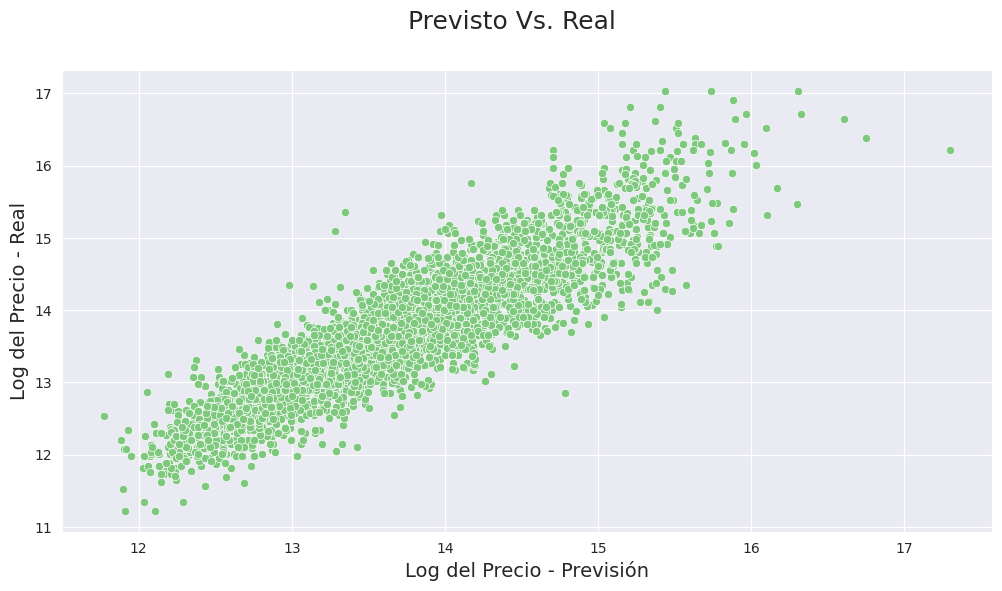

In [ ]:
ax = sns.scatterplot(x=y_previsto_train, y=y_train)
ax.figure.set_size_inches(12,6)
ax.figure.suptitle('Previsto Vs. Real',fontsize=18)
ax.set_xlabel('Log del Precio - Previsión',fontsize=14)
ax.set_ylabel('Log del Precio - Real',fontsize=14)
ax;

## Obteniendo los resíduos

In [ ]:
residuo = y_train - y_previsto_train

## Graficando la distribución de frecuencias de los resíduos

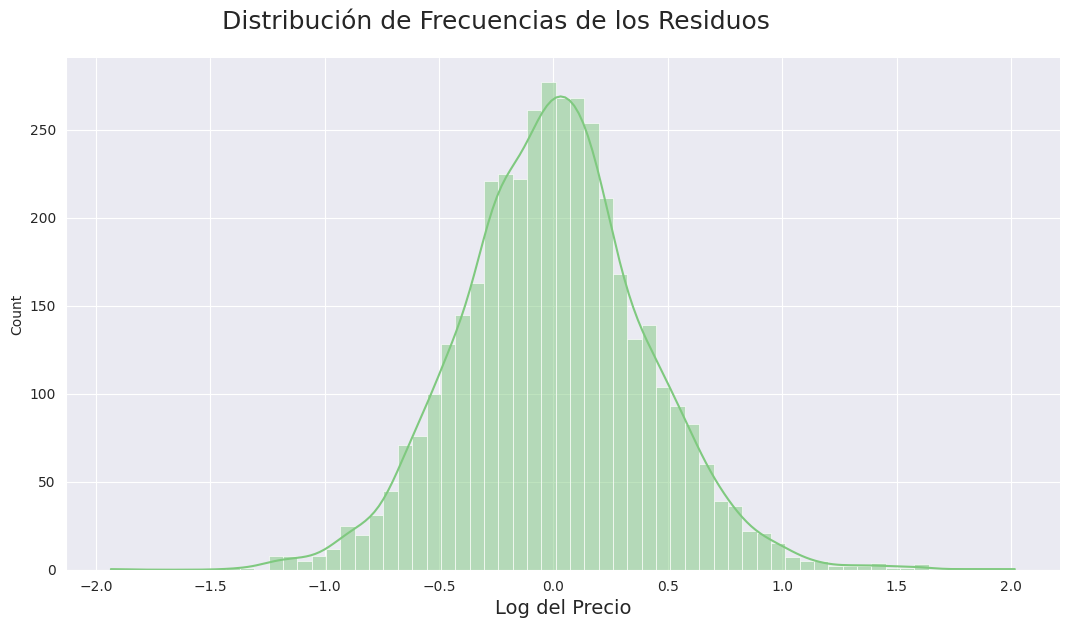

In [ ]:
ax = sns.displot(residuo, kde=True)
ax.figure.set_size_inches(12,6)
ax.figure.suptitle('Distribución de Frecuencias de los Residuos',fontsize=18,y=1.05)
ax.set_xlabels('Log del Precio',fontsize=14)
ax;

---

### 📚 Apunte Teórico: Auditoría de Residuos y Supuestos de Gauss-Markov

Para que un modelo OLS (Mínimos Cuadrados Ordinarios) sea confiable y se considere el **MELI** (Mejor Estimador Lineal Insesgado, o *BLUE* en inglés, según el Teorema de Gauss-Markov), sus errores o "residuos" deben cumplir ciertas reglas estrictas. En el mundo de los negocios, violar estas reglas significa que el algoritmo tiene un "sesgo ciego" y hará perder dinero a la empresa.

**1. Gráfico de Dispersión (Previsto vs. Real): La Prueba de Precisión**

* **Objetivo Matemático:** Evaluar la bondad de ajuste visual.
* **Lógica de Negocio:** Si el tasador fuera perfecto, cada punto caería exactamente sobre una línea diagonal imaginaria de 45 grados (donde el precio previsto es exactamente igual al real). La dispersión alrededor de esta línea nos muestra el margen de negociación o error en la vida real.

**2. Histograma de Residuos: La Prueba de Imparcialidad (Normalidad)**

* **Objetivo Matemático:** Validar que los errores ($Y_{Real} - \hat{Y}_{Previsto}$) se distribuyan de forma normal (Campana de Gauss) con media igual a cero ($\mu = 0$).
* **Lógica de Negocio:** Un error promedio de cero significa que el modelo es **imparcial**. A veces tasa un poco por encima y a veces un poco por debajo, pero los errores se compensan. Si la campana estuviera desplazada (ej. hacia la izquierda), significaría que el software sufre de un sesgo sistemático (ej. siempre subvalora las propiedades, lo que enojaría a los clientes vendedores de la PyME).

---

### 💻 Script Senior: Dashboard de Auditoría Visual (Clean Code)


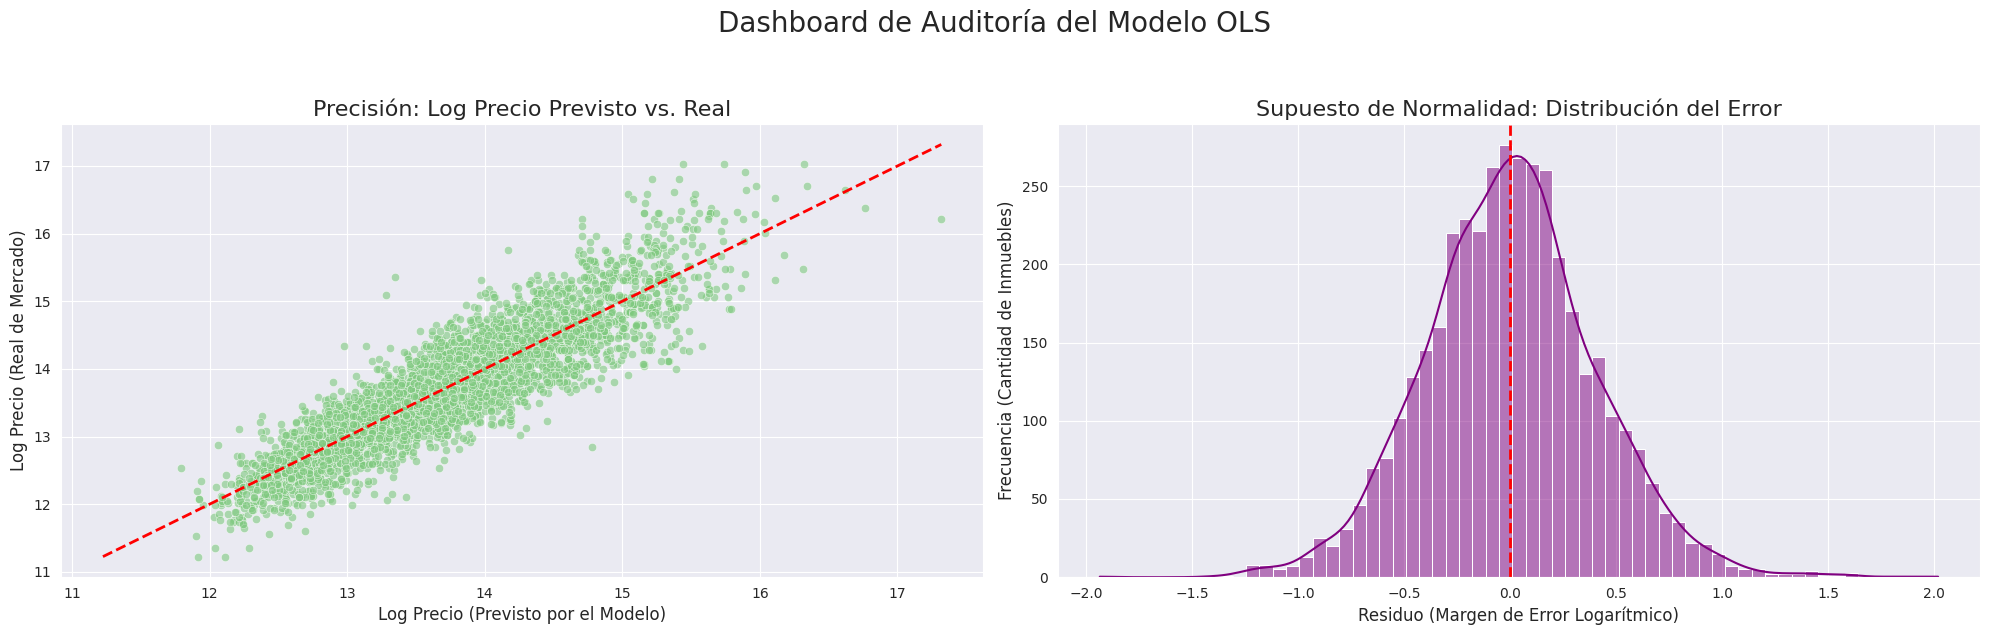

In [60]:

# Asumimos importados numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns y el modelo entrenado.

def auditar_rendimiento_y_residuos(y_real: pd.Series, y_previsto: np.ndarray) -> None:
    """
    Genera un panel gerencial (1x2) para auditar visualmente la precisión del modelo
    y validar el supuesto estadístico de Normalidad de los residuos.
    """
    # 1. Cálculo del margen de error (Residuos)
    residuos = y_real - y_previsto

    # 2. Configuración de la Arquitectura Visual (Subplots)
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    fig.suptitle('Dashboard de Auditoría del Modelo OLS', fontsize=20, y=1.05)

    # --- PANEL IZQUIERDO: Previsto vs Real ---
    sns.scatterplot(x=y_previsto, y=y_real, ax=axes[0], alpha=0.6)

    # Añadimos la línea de "Predicción Perfecta" (45 grados) para referencia visual
    min_val = min(y_real.min(), y_previsto.min())
    max_val = max(y_real.max(), y_previsto.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

    axes[0].set_title('Precisión: Log Precio Previsto vs. Real', fontsize=16)
    axes[0].set_xlabel('Log Precio (Previsto por el Modelo)', fontsize=12)
    axes[0].set_ylabel('Log Precio (Real de Mercado)', fontsize=12)

    # --- PANEL DERECHO: Distribución de Residuos ---
    sns.histplot(residuos, kde=True, ax=axes[1], color='purple')

    # Añadimos la línea de Media Cero (Imparcialidad del modelo)
    axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)

    axes[1].set_title('Supuesto de Normalidad: Distribución del Error', fontsize=16)
    axes[1].set_xlabel('Residuo (Margen de Error Logarítmico)', fontsize=12)
    axes[1].set_ylabel('Frecuencia (Cantidad de Inmuebles)', fontsize=12)

    plt.tight_layout()
    plt.show()

# ==============================================================================
# EJECUCIÓN DEL DASHBOARD
# ==============================================================================
# Generamos las previsiones sobre los datos que el modelo ya conoce (Train)
y_previsto_train = modelo_sklearn.predict(X_train)

# Ejecutamos nuestra función de auditoría
auditar_rendimiento_y_residuos(y_real=y_train, y_previsto=y_previsto_train)


# 🗺️ Mapa del Pipeline Completo: Arquitectura del Modelo Predictivo Inmobiliario


---

Este es el flujo de trabajo integral (*End-to-End*) que transforma datos crudos en un tasador automático confiable.

**FASE I: DIAGNÓSTICO Y CURACIÓN DE DATOS (Data Engineering)**

* **Paso 1: Ingesta y Diagnóstico Estructural** (`pandas`)
* Lectura de datos y revisión de nulos (`.info()`).
* Auditoría de asimetría (`.describe()`) y fuerza lineal inicial (`.corr()`).


* **Paso 2: Auditoría Visual (EDA)** (`seaborn`, `matplotlib`)
* Detección de problemas que romperían el modelo: Asimetría Positiva (cola derecha en precio) y Heterocedasticidad (margen de error en forma de embudo).


* **Paso 3: Transformación Matemática** (`numpy`)
* Aplicación de `np.log1p()` a *Target* y *Predictores* para "domar la varianza", linealizar la relación y cumplir el supuesto de normalidad.



**FASE II: ENTRENAMIENTO Y AUDITORÍA ESTADÍSTICA (Data Science)**

* **Paso 4: La Prueba de Fuego (Train/Test Split)** (`sklearn`)
* Segmentación (80% Entrenamiento / 20% Prueba) para garantizar que el modelo sabe predecir en el mundo real y no solo sufre de *Sobreajuste* (Overfitting).


* **Paso 5: Auditoría Algorítmica** (`statsmodels`)
* Diagnóstico con OLS `.summary()`.
* Filtro de variables tóxicas usando el **p-valor**. Aplicación del **Principio de Parsimonia** (eliminación de `Dist_Farmacia` por ser ruido estadístico).



**FASE III: DESPLIEGUE Y NEGOCIO (MLOps)**

* **Paso 6: El Motor Predictivo** (`sklearn`)
* Instanciación, ajuste (`.fit()`) y evaluación (`.score()`) usando `LinearRegression()`. Validación de estabilidad comparando el $R^2$ de Train vs Test.


* **Paso 7: El Simulador (Inferencia y Elasticidad)** (`numpy`)
* Ingreso de nuevos datos, transformación ($log$) e inversión matemática con `np.expm1()` para entregar el precio en USD.
* Lectura de los Coeficientes como **Elasticidades** (Ej: *Un +1% en Área = +1.06% en USD*).


* **Paso 8: Validación de Imparcialidad** (`seaborn`, `matplotlib`)
* Dashboard final de **Residuos**. Verificación visual del Teorema de Gauss-Markov: Campana de Gauss centrada en cero para asegurar que el tasador no tiene sesgos sistemáticos que hagan perder dinero a la empresa.



---